In [2]:
!pip install ultralytics opencv-python -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.1 MB/s eta 0:00:00


In [3]:
from google.colab import files
uploaded = files.upload()   # choose pedistrian.jpg
print(list(uploaded.keys()))  # confirm the exact saved filename

Saving ped.webp to ped.webp
['ped.webp']



0: 448x640 1 person, 1 car, 472.1ms
Speed: 18.4ms preprocess, 472.1ms inference, 37.8ms postprocess per image at shape (1, 3, 448, 640)


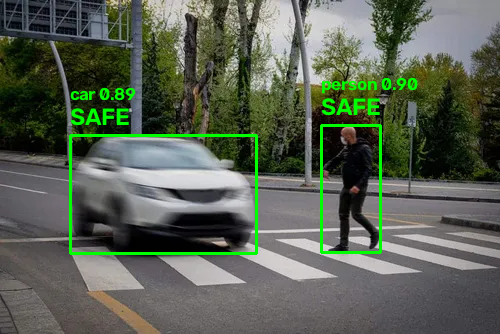

In [7]:
import cv2
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

# Load YOLOv8 model
model = YOLO("yolov8n.pt")

# Load parking image — match filename exactly to what !ls/uploaded.keys() showed
image = cv2.imread("ped.webp")
assert image is not None, "Image not found — check filename with !ls"

# Run object detection
results = model(image)

# Copy image
output = image.copy()

for result in results:
    boxes = result.boxes

    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        confidence = float(box.conf[0])
        class_id = int(box.cls[0])
        label = model.names[class_id]

        width = x2 - x1
        height = y2 - y1
        area = width * height

        if area > 120000:
            warning = "STOP!"
            color = (0, 0, 255)
        elif area > 60000:
            warning = "BRAKE NOW"
            color = (0, 140, 255)
        elif area > 25000:
            warning = "SLOW DOWN"
            color = (0, 255, 255)
        else:
            warning = "SAFE"
            color = (0, 255, 0)

        cv2.rectangle(output, (x1, y1), (x2, y2), color, 2)
        cv2.putText(output, f"{label} {confidence:.2f}", (x1, y1 - 35),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
        cv2.putText(output, warning, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

cv2_imshow(output)